<a href="https://colab.research.google.com/github/UTD2026/Mixed_Dataset_Testing_STA/blob/main/LabelFree_Router_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Does a deployable label-free router exist? Within-model confidence vs cross-model disagreement

The go/no-go for the exploitation claim. Your `ce_q` router collapsed to 100%-adapted, and
`ce_out` only works because it teacher-forces the gold answer (not deployable). This tests
whether **any label-free signal separates base-correct from base-wrong** well enough to route
between the base and a test-time adapter.

Two signal families, both label-free:
- **within-model**: base's confidence in its *own* greedy answer (mean token prob, entropy) and
  self-consistency. (The CMP paper reports these are weak on confident errors -- we verify.)
- **cross-model (CMP-style)**: how surprised the *adapter* is at the *base's* answer, and vice
  versa. Your base+adapter give this for free; predicted to beat within-model.

Outputs: **AUROC** of each signal for base-correctness (the threshold-free ceiling on any router),
and the **routed-accuracy curve** each signal delivers vs base / adapt-all / oracle. Run per
adapter arm (`route_region` = the specialist, `full` = adapt-all).

If AUROC clears ~0.7 (esp. cross-model): a deployable router exists -> exploitation claim is on the
table. If it hovers ~0.55: no label-free router -> the paper stays the phenomenon, honestly.

In [1]:
# ---- repo / runtime knobs ----
REPO_URL = "https://github.com/UTD2026/rishabh-tlm.git"
WORK = "/content/v2_dynamic_ce"                       # change if not on Colab
LOCAL_REPO_ZIP = "/content/rishabh-tlm-ab-routing-2026-07-02.zip"  # clone fallback
GITHUB_TOKEN_ENV = "GITHUB_TOKEN"                     # optional, for private clone
MODEL = "Qwen/Qwen3.5-0.8B"
DATASETS = ["logiqa", "medicine", "geography"]        # geography = honest negative case
N_BY_DATASET = {"logiqa": 1000, "medicine": 1000, "geography": 225}
print({"work": WORK, "model": MODEL, "datasets": DATASETS})


{'work': '/content/v2_dynamic_ce', 'model': 'Qwen/Qwen3.5-0.8B', 'datasets': ['logiqa', 'medicine', 'geography']}


## Environment setup

Written for a CUDA GPU box (Colab/H200/Ada). Skip the install cell if your image already has these packages.

In [2]:
import os, sys, subprocess, json, textwrap, shutil, pathlib, time
from pathlib import Path

Path(WORK).mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
print("cwd:", os.getcwd())

cwd: /content/v2_dynamic_ce


In [3]:
# Fresh Colab runtime install / compatibility setup.
# Qwen3.5 needs newer Transformers support. Generation is patched to use Transformers,
# because Colab/vLLM CUDA wheels can mismatch (e.g. libcudart.so.13 missing).
# Runtime > Restart runtime after this cell if pip asks or if imports still show stale versions.
import os, sys, subprocess, shutil

INSTALL_DEPS = True
USE_QWEN35_COMPAT_INSTALL = True  # keep True for MODEL="Qwen/Qwen3.5-0.8B"
INSTALL_VLLM = False  # keep False on Colab unless you have a known-compatible vLLM/CUDA wheel

if INSTALL_DEPS:
    def pip_install(*args):
        cmd = [sys.executable, "-m", "pip", "install", "-U", *args]
        print("RUN:", " ".join(cmd))
        subprocess.check_call(cmd)

    pip_install("pip")
    pip_install("peft", "accelerate", "scipy", "sympy", "ninja", "pandas", "matplotlib", "torchvision", "pillow", "huggingface_hub")

    if USE_QWEN35_COMPAT_INSTALL and "Qwen3.5" in MODEL:
        # HF model card recommends latest Transformers for Qwen3.5.
        pip_install("transformers[serving] @ git+https://github.com/huggingface/transformers.git@main")
    else:
        pip_install("transformers")

    if INSTALL_VLLM:
        # Optional only. The notebook patches ab_generate.py to use Transformers by default.
        # Use this only if your runtime has a vLLM wheel matching its CUDA/PyTorch stack.
        try:
            cmd = [sys.executable, "-m", "pip", "install", "-U", "vllm", "--extra-index-url", "https://wheels.vllm.ai/nightly"]
            print("RUN:", " ".join(cmd))
            subprocess.check_call(cmd)
        except Exception as e:
            print("Nightly vLLM install failed, falling back to normal vLLM:", repr(e))
            pip_install("vllm")

    # Qwen3.5 GDN Triton JIT expects ninja on PATH in this codebase's README.
    ninja = shutil.which("ninja")
    if ninja:
        print("ninja:", ninja)
    else:
        print("WARNING: ninja still not found on PATH")

import torch, transformers
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("transformers:", transformers.__version__)
if INSTALL_VLLM:
    try:
        import vllm
        print("vllm:", getattr(vllm, "__version__", "unknown"))
    except Exception as e:
        print("vllm import warning:", repr(e))
else:
    print("vllm skipped; ab_generate.py will use Transformers fallback")


RUN: /usr/bin/python3 -m pip install -U pip
RUN: /usr/bin/python3 -m pip install -U peft accelerate scipy sympy ninja pandas matplotlib torchvision pillow huggingface_hub
RUN: /usr/bin/python3 -m pip install -U transformers[serving] @ git+https://github.com/huggingface/transformers.git@main
ninja: /usr/local/bin/ninja
torch: 2.12.1+cu130
cuda available: True
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
transformers: 5.14.0.dev0
vllm skipped; ab_generate.py will use Transformers fallback


### Fix CUDA / optional-dependency mismatches (torchaudio, torchvision, torchao)

Current Colab images carry several optional extensions that are *installed but version- or
CUDA-mismatched*, and the git-main `transformers` / `peft` treat "present but incompatible" as
a hard error instead of "absent, skip it":

- `torchaudio` is built for CUDA 12.8 against a CUDA-13 PyTorch. `transformers` imports it while
  loading **text** model modules (`peft` -> `BloomPreTrainedModel` -> `loss_utils` -> `loss_rnnt`),
  so its CUDA check crashes the whole pipeline.
- `torchao` ships as 0.10.0, but `peft`'s LoRA dispatcher requires > 0.16.0 and *raises* from
  `is_torchao_available()` during `get_peft_model(...)` even though this LoRA config uses plain
  `Linear` layers and never needs torchao.
- `torchvision` can mismatch CUDA the same way as torchaudio.

None of these are used by this text-only pipeline (no audio, no vision, no quantization), so we
remove them. Once each is absent, the corresponding `is_*_available()` guard returns `False` and
the code skips it cleanly. The cell then forces the exact import + LoRA path the subprocesses use,
so any remaining mismatch surfaces here instead of deep inside a stage.

In [4]:
import sys, subprocess

def _pip(*args):
    print("RUN: pip", *args)
    subprocess.check_call([sys.executable, "-m", "pip", *args])

# Remove optional extensions that are installed-but-incompatible (unused by this pipeline).
for pkg in ["torchaudio", "torchvision", "torchao"]:
    try:
        _pip("uninstall", "-y", pkg)
    except Exception as e:
        print(f"(uninstall {pkg} skipped: {e!r})")

# Drop any half-loaded modules so the verification imports are clean.
for m in list(sys.modules):
    if m.startswith(("torchaudio", "torchvision", "torchao", "transformers", "peft")):
        del sys.modules[m]

import torch
print("torch:", torch.__version__, "| cuda build:", torch.version.cuda, "| cuda avail:", torch.cuda.is_available())

# Force the exact eager chain the subprocesses trigger: text-model import + a LoRA injection.
from transformers import AutoModelForCausalLM, AutoTokenizer, BloomPreTrainedModel  # noqa: F401
from peft import LoraConfig, TaskType, get_peft_model  # noqa: F401
import torch.nn as nn
_probe = nn.Linear(8, 8)
class _Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(8, 8)
    def forward(self, x):
        return self.proj(x)
_ = get_peft_model(_Tiny(), LoraConfig(target_modules=["proj"], r=2))  # exercises the LoRA dispatcher
print("transformers + peft + LoRA dispatch OK (no torchaudio/torchao crash)")


RUN: pip uninstall -y torchaudio
RUN: pip uninstall -y torchvision
RUN: pip uninstall -y torchao
torch: 2.12.1+cu130 | cuda build: 13.0 | cuda avail: True
transformers + peft + LoRA dispatch OK (no torchaudio/torchao crash)


In [5]:
# Clone / update repo, with token + zip fallback
import os, subprocess, shutil, zipfile, glob
from pathlib import Path

repo_dir = Path(WORK) / "rishabh-tlm"


def _run_capture(cmd, cwd=None):
    """Run a shell command and return CompletedProcess while preserving stdout/stderr."""
    return subprocess.run(
        [str(x) for x in cmd],
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )


def _clone_url_with_optional_token(url: str) -> str:
    token = os.environ.get(GITHUB_TOKEN_ENV, "").strip()
    if token and url.startswith("https://github.com/"):
        # Do not print this URL; it contains a secret.
        return url.replace("https://", f"https://{token}@", 1)
    return url


def _unzip_repo(zip_path: Path, dest: Path):
    zip_path = Path(zip_path).expanduser().resolve()
    if not zip_path.exists():
        raise FileNotFoundError(f"Repo zip does not exist: {zip_path}")

    print(f"Using repo zip fallback: {zip_path}")
    tmp = dest.parent / "_repo_zip_extract_tmp"
    if tmp.exists():
        shutil.rmtree(tmp)
    tmp.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(tmp)

    # Common cases: zip contains a single top-level folder, or contains repo files directly.
    candidates = [p for p in tmp.iterdir() if p.is_dir()]
    selected = None
    for cand in candidates:
        if (cand / "cuda_ttl" / "ab_routing").exists() or (cand / ".git").exists():
            selected = cand
            break
    if selected is None:
        if (tmp / "cuda_ttl" / "ab_routing").exists():
            selected = tmp
        elif len(candidates) == 1:
            selected = candidates[0]
        else:
            raise RuntimeError(
                "Could not identify repo root inside zip. "
                f"Top-level entries: {[p.name for p in tmp.iterdir()][:20]}"
            )

    if dest.exists():
        shutil.rmtree(dest)
    if selected == tmp:
        shutil.copytree(tmp, dest, dirs_exist_ok=True)
        shutil.rmtree(tmp, ignore_errors=True)
    else:
        shutil.move(str(selected), str(dest))
        shutil.rmtree(tmp, ignore_errors=True)

    if not (dest / "cuda_ttl" / "ab_routing").exists():
        raise RuntimeError(f"Unzipped repo does not contain cuda_ttl/ab_routing: {dest}")


def _find_repo_zip():
    """Find an already-present repo zip in the locations Colab commonly uses."""
    explicit = Path(LOCAL_REPO_ZIP).expanduser()
    search_roots = [
        explicit.parent,
        Path(WORK),
        Path.cwd(),
        Path("/content"),
        Path("/mnt/data"),  # works in ChatGPT sandbox, harmless in Colab if absent
    ]

    candidates = []
    if explicit.exists():
        candidates.append(explicit)
    for root in search_roots:
        try:
            if root.exists():
                candidates.extend(Path(x) for x in glob.glob(str(root / "rishabh-tlm*.zip")))
        except Exception:
            pass

    # de-dupe while preserving order
    out = []
    seen = set()
    for c in candidates:
        try:
            resolved = c.resolve()
        except Exception:
            continue
        if c.exists() and resolved not in seen:
            out.append(c)
            seen.add(resolved)
    return out[0] if out else None


def _upload_repo_zip_colab():
    """Upload a zip in Colab and return the actual path it was written to.

    Colab saves uploads into the current working directory, not necessarily /content.
    The previous notebook assumed /content/<name>, which caused FileNotFoundError.
    This version verifies the path and falls back to writing uploaded bytes manually.
    """
    from google.colab import files

    print("No local repo zip found. Upload rishabh-tlm-ab-routing-2026-07-02.zip now.")
    uploaded = files.upload()
    zip_names = [name for name in uploaded if name.lower().endswith(".zip")]
    if not zip_names:
        raise RuntimeError("No .zip file uploaded.")

    name = zip_names[0]
    candidates = [
        Path.cwd() / name,
        Path(WORK) / name,
        Path("/content") / name,
        Path(name),
    ]
    for candidate in candidates:
        if candidate.exists():
            print(f"Uploaded zip found at: {candidate.resolve()}")
            return candidate.resolve()

    # Defensive fallback: Colab returned bytes, so write them somewhere we control.
    fallback = Path(WORK) / name
    fallback.parent.mkdir(parents=True, exist_ok=True)
    fallback.write_bytes(uploaded[name])
    print(f"Uploaded zip bytes written to: {fallback.resolve()}")
    return fallback.resolve()


if repo_dir.exists():
    print("repo already exists:", repo_dir)
    # keep this non-destructive; uncomment if you explicitly want latest remote
    # subprocess.check_call(["git", "-C", str(repo_dir), "pull"])
else:
    clone_url = _clone_url_with_optional_token(REPO_URL)
    print("Cloning repo...")
    cp = _run_capture(["git", "clone", clone_url, str(repo_dir)])
    if cp.returncode != 0:
        print("git clone failed.")
        if cp.stdout.strip():
            print("--- git stdout ---")
            print(cp.stdout[-4000:])
        if cp.stderr.strip():
            print("--- git stderr ---")
            # Redact token if present.
            safe_stderr = cp.stderr
            token = os.environ.get(GITHUB_TOKEN_ENV, "").strip()
            if token:
                safe_stderr = safe_stderr.replace(token, "<GITHUB_TOKEN>")
            print(safe_stderr[-4000:])

        zip_path = _find_repo_zip()
        if zip_path is None:
            try:
                zip_path = _upload_repo_zip_colab()
            except Exception as upload_e:
                raise RuntimeError(
                    "Could not clone the repo and no repo zip fallback was available.\n\n"
                    "Most likely causes:\n"
                    "1) The GitHub repo is private and Colab has no auth. Set os.environ['GITHUB_TOKEN'] first.\n"
                    "2) The URL/branch is wrong or unavailable.\n"
                    "3) Colab/network blocked GitHub.\n\n"
                    f"Original git error:\n{cp.stderr[-2000:]}"
                ) from upload_e

        _unzip_repo(Path(zip_path), repo_dir)

os.chdir(repo_dir)
print("repo:", repo_dir)
try:
    head = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True, stderr=subprocess.DEVNULL).strip()
    print("git head:", head)
except Exception:
    print("git head unavailable: repo loaded from zip or non-git folder")

print("ab_routing files:")
for p in sorted((repo_dir / "cuda_ttl" / "ab_routing").glob("ab_*.py")):
    print(" -", p.relative_to(repo_dir))


Cloning repo...
git clone failed.
--- git stderr ---
Cloning into '/content/v2_dynamic_ce/rishabh-tlm'...
fatal: could not read Username for 'https://github.com': No such device or address

No local repo zip found. Upload rishabh-tlm-ab-routing-2026-07-02.zip now.


Saving rishabh-tlm-ab-routing-2026-07-02.zip to rishabh-tlm-ab-routing-2026-07-02.zip
Uploaded zip found at: /content/v2_dynamic_ce/rishabh-tlm-ab-routing-2026-07-02.zip
Using repo zip fallback: /content/v2_dynamic_ce/rishabh-tlm-ab-routing-2026-07-02.zip
repo: /content/v2_dynamic_ce/rishabh-tlm
git head unavailable: repo loaded from zip or non-git folder
ab_routing files:
 - cuda_ttl/ab_routing/ab_build_pool.py
 - cuda_ttl/ab_routing/ab_generate.py
 - cuda_ttl/ab_routing/ab_route_eval.py
 - cuda_ttl/ab_routing/ab_train_ttl.py


In [6]:
# Runtime patch: make model loading more robust for Qwen3.5 and add clear preflight checks.
# This is non-destructive to the repo ZIP; it only edits the working copy inside WORK.
from pathlib import Path
import subprocess, sys, os

if not Path("cuda_ttl/ab_routing/ab_build_pool.py").exists():
    raise FileNotFoundError("Run the repo setup cell first; cuda_ttl/ab_routing/ab_build_pool.py not found.")

# 1) ab_build_pool.py originally hard-coded AutoModelForCausalLM.
# For Qwen3.5, use the checkpoint-declared architecture when Transformers knows it;
# otherwise fall back to AutoModelForCausalLM.
p = Path("cuda_ttl/ab_routing/ab_build_pool.py")
s = p.read_text()
s = s.replace(
    '    from transformers import AutoModelForCausalLM, AutoTokenizer\n'
    '    from peft import LoraConfig, TaskType, get_peft_model\n'
    '    tokenizer = AutoTokenizer.from_pretrained(args.model)\n'
    '    model = AutoModelForCausalLM.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n'
    '                                                 device_map="cuda")\n',
    '    import transformers\n'
    '    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer\n'
    '    from peft import LoraConfig, TaskType, get_peft_model\n'
    '    tokenizer = AutoTokenizer.from_pretrained(args.model, trust_remote_code=True)\n'
    '    cfg = AutoConfig.from_pretrained(args.model, trust_remote_code=True)\n'
    '    arch = (getattr(cfg, "architectures", None) or [""])[0]\n'
    '    model_cls = getattr(transformers, arch, None) or AutoModelForCausalLM\n'
    '    print(f"loading with {model_cls.__name__}")\n'
    '    model = model_cls.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n'
    '                                      device_map="cuda", trust_remote_code=True)\n'
)
p.write_text(s)

# 2) Add trust_remote_code to train loader too, same idea.
p = Path("cuda_ttl/ab_routing/ab_train_ttl.py")
s = p.read_text()
s = s.replace('    tokenizer = AutoTokenizer.from_pretrained(args.model)\n', '    tokenizer = AutoTokenizer.from_pretrained(args.model, trust_remote_code=True)\n')
s = s.replace('    cfg = AutoConfig.from_pretrained(args.model)\n', '    cfg = AutoConfig.from_pretrained(args.model, trust_remote_code=True)\n')
s = s.replace('    model = model_cls.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n                                      device_map="cuda")\n',
              '    model = model_cls.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n                                      device_map="cuda", trust_remote_code=True)\n')
p.write_text(s)

# 3) Hard preflight before burning time.
import torch, transformers
from transformers import AutoConfig, AutoTokenizer
print("MODEL =", MODEL)
print("torch =", torch.__version__)
print("transformers =", transformers.__version__)
print("cuda =", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. In Colab: Runtime -> Change runtime type -> GPU.")
print("gpu =", torch.cuda.get_device_name(0))
try:
    tok = AutoTokenizer.from_pretrained(MODEL, trust_remote_code=True)
    cfg = AutoConfig.from_pretrained(MODEL, trust_remote_code=True)
    print("model_type =", getattr(cfg, "model_type", None))
    print("architectures =", getattr(cfg, "architectures", None))
    print("tokenizer ok; chat_template =", bool(getattr(tok, "chat_template", None)))
except Exception as e:
    raise RuntimeError(
        "Model/tokenizer preflight failed. If MODEL is Qwen/Qwen3.5-0.8B, rerun the install cell, "
        "restart runtime if needed, or set MODEL='Qwen/Qwen2.5-0.5B-Instruct' for a text-only smoke test."
    ) from e

print("patched scripts ok")
for file in ["ab_build_pool.py", "ab_train_ttl.py"]:
    subprocess.check_call([sys.executable, "-m", "py_compile", str(Path("cuda_ttl/ab_routing") / file)])
    print("py_compile ok:", file)


MODEL = Qwen/Qwen3.5-0.8B
torch = 2.12.1+cu130
transformers = 5.14.0.dev0
cuda = True
gpu = NVIDIA RTX PRO 6000 Blackwell Server Edition


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

model_type = qwen3_5
architectures = ['Qwen3_5ForConditionalGeneration']
tokenizer ok; chat_template = True
patched scripts ok
py_compile ok: ab_build_pool.py
py_compile ok: ab_train_ttl.py


In [7]:
# Data paths expected by cuda_ttl/ab_routing/run_ab.sh, but we call scripts directly.
DATA_FILES = {
    "logiqa": "data/AdaptEval/logiqa_random_5k.json",
    "medicine": "data/AdaptEval/medicine_mcqa_random_5k.json",
    "geography": "data/AdaptEval/geography_mmlu.json",
    "gsm8k": "data/AdaptEval/gsm8k_random_5k.json",
}

missing = [p for ds, p in DATA_FILES.items() if ds in DATASETS and not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Missing dataset files: " + ", ".join(missing) +
        "\nThe uploaded repo snapshot included these under data/AdaptEval/. If your clone does not, copy them there before running."
    )

for ds in DATASETS:
    print(ds, "->", DATA_FILES[ds], "exists", Path(DATA_FILES[ds]).exists())

logiqa -> data/AdaptEval/logiqa_random_5k.json exists True
medicine -> data/AdaptEval/medicine_mcqa_random_5k.json exists True
geography -> data/AdaptEval/geography_mmlu.json exists True


In [8]:
# ---- resolve paths (cwd is the repo root after the clone cell) ----
from pathlib import Path
SCRIPTS = Path("cuda_ttl/ab_routing").resolve()
REPO_DIR = Path.cwd()
ARTIFACT_ROOT = Path(WORK) / "saves_dynamic_v2ce"   # reuse prior pools/base preds if present
ANCHOR_ROOT = Path(WORK) / "saves_anchor"           # this experiment's outputs
ANCHOR_ROOT.mkdir(parents=True, exist_ok=True)
assert SCRIPTS.exists(), "run the clone cell first"
print("repo:", REPO_DIR, "| scripts:", SCRIPTS)


repo: /content/v2_dynamic_ce/rishabh-tlm | scripts: /content/v2_dynamic_ce/rishabh-tlm/cuda_ttl/ab_routing


## Write the anchored trainer

Writes `ab_train_ttl_anchored.py` (vanilla objective at `--anchor-lambda 0` plus the anchor flags) and the HF `ab_generate.py`. Both are py-compiled here so a syntax problem surfaces before any GPU time.

In [9]:
# ---- write the anchored trainer and the HF generation script into the repo ----
import subprocess, sys
from pathlib import Path

trainer_src = "#!/usr/bin/env python\n\"\"\"\nStage 2: TTL LoRA training on the admission-selected pool \u2014 CUDA port of\nmlx_ttl/train_ttl_mlx.py in its --selection-file mode (CE gate bypassed; train ONLY on\nthe selected idxs, weighted). Same recipe: chat-templated (user, assistant=output)\npairs, loss on completion tokens only, LoRA q_proj+v_proj r8 alpha16 dropout0 on all\nlayers, AdamW lr 5e-5, cosine schedule with 10% warmup, 1 epoch, batch 1, seed 42.\n\nSaves the peft adapter AND a merged full model (merge_and_unload) so vLLM generation\ncannot silently no-op the adapter (the vLLM-0.24 LoRA module-naming gotcha).\n\"\"\"\n\nimport argparse\nimport json\nimport math\nimport os\nimport random\nimport time\n\nimport torch\n\n\ndef build_user(rec):\n    if \"instruction\" in rec:\n        instruction = (rec.get(\"instruction\") or \"\").strip()\n        extra = (rec.get(\"input\") or \"\").strip()\n        return instruction + ((\"\\n\" + extra) if extra else \"\")\n    return (rec.get(\"question\") or \"\").strip()\n\n\ndef chat_ids(tokenizer, msgs, add_generation_prompt):\n    # template to STRING then encode (BatchEncoding gotcha \u2014 see ab_build_pool.py)\n    try:\n        text = tokenizer.apply_chat_template(\n            msgs, tokenize=False, add_generation_prompt=add_generation_prompt,\n            enable_thinking=False)\n    except TypeError:\n        text = tokenizer.apply_chat_template(\n            msgs, tokenize=False, add_generation_prompt=add_generation_prompt)\n    return tokenizer.encode(text, add_special_tokens=False)\n\n\ndef main():\n    ap = argparse.ArgumentParser(description=\"TTL LoRA on a selected pool (CUDA)\")\n    ap.add_argument(\"--model\", default=\"Qwen/Qwen3.5-0.8B\")\n    ap.add_argument(\"--data\", required=True)\n    ap.add_argument(\"--selection-file\", required=True)\n    ap.add_argument(\"--output-dir\", required=True)\n    ap.add_argument(\"--merged-dir\", default=None, help=\"default <output-dir>/merged\")\n    ap.add_argument(\"--max-samples\", type=int, default=1000)\n    ap.add_argument(\"--max-seq-length\", type=int, default=2048)\n    ap.add_argument(\"--epochs\", type=float, default=1.0)\n    ap.add_argument(\"--learning-rate\", type=float, default=5e-5)\n    ap.add_argument(\"--warmup-ratio\", type=float, default=0.1)\n    ap.add_argument(\"--lora-rank\", type=int, default=8)\n    ap.add_argument(\"--lora-alpha\", type=int, default=16)\n    ap.add_argument(\"--lora-keys\", default=\"q_proj,v_proj\")\n    ap.add_argument(\"--seed\", type=int, default=42)\n    # --- base-anchor (confidence-weighted KL to frozen base) ---\n    ap.add_argument(\"--anchor-lambda\", type=float, default=0.0,\n                    help=\"strength of the base-anchor term; 0.0 == vanilla TLM\")\n    ap.add_argument(\"--anchor-weight\", default=\"confidence\",\n                    choices=[\"confidence\", \"threshold\", \"uniform\"],\n                    help=\"per-token weight on the anchor: confidence=base gold-prob^gamma, \"\n                         \"threshold=1 where base gold-CE<=tau, uniform=1 everywhere\")\n    ap.add_argument(\"--anchor-direction\", default=\"fwd\", choices=[\"fwd\", \"rev\"],\n                    help=\"fwd=KL(base||adapted) (pull adapted toward base); rev=KL(adapted||base)\")\n    ap.add_argument(\"--anchor-tau\", type=float, default=0.3,\n                    help=\"base gold-token CE threshold for --anchor-weight threshold\")\n    ap.add_argument(\"--anchor-gamma\", type=float, default=1.0,\n                    help=\"sharpening exponent for --anchor-weight confidence\")\n    args = ap.parse_args()\n    merged_dir = args.merged_dir or os.path.join(args.output_dir, \"merged\")\n    os.makedirs(args.output_dir, exist_ok=True)\n\n    torch.manual_seed(args.seed)\n    sel = json.load(open(args.selection_file))\n    weights = {int(e[\"idx\"]): float(e[\"weight\"]) for e in sel[\"selected\"]}\n\n    import transformers\n    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, get_cosine_schedule_with_warmup\n    from peft import LoraConfig, TaskType, get_peft_model\n    tokenizer = AutoTokenizer.from_pretrained(args.model)\n    # Load via the checkpoint's own architecture class (Qwen3_5ForConditionalGeneration),\n    # NOT AutoModelForCausalLM: the latter returns the text submodel, whose merged\n    # save_pretrained writes a Qwen3_5TextConfig that vLLM refuses to load.\n    cfg = AutoConfig.from_pretrained(args.model)\n    arch = (getattr(cfg, \"architectures\", None) or [\"\"])[0]\n    model_cls = getattr(transformers, arch, None) or AutoModelForCausalLM\n    print(f\"loading with {model_cls.__name__}\")\n    model = model_cls.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n                                      device_map=\"cuda\")\n    model = get_peft_model(model, LoraConfig(\n        task_type=TaskType.CAUSAL_LM, r=args.lora_rank, lora_alpha=args.lora_alpha,\n        lora_dropout=0.0, bias=\"none\",\n        target_modules=[k.strip() for k in args.lora_keys.split(\",\")]))\n    model.print_trainable_parameters()\n    device = next(model.parameters()).device\n\n    records = json.load(open(args.data, encoding=\"utf-8\"))[: args.max_samples]\n    samples = []  # (full_ids, prompt_len, idx)\n    for idx, rec in enumerate(records):\n        if idx not in weights:\n            continue\n        user = build_user(rec)\n        output = str(rec.get(\"output\") if \"output\" in rec else rec.get(\"answers\", \"\") or \"\")\n        if not user:\n            continue\n        prompt_ids = chat_ids(tokenizer, [{\"role\": \"user\", \"content\": user}], True)\n        full_ids = chat_ids(tokenizer, [{\"role\": \"user\", \"content\": user},\n                                        {\"role\": \"assistant\", \"content\": output}], False)\n        full_ids = full_ids[: args.max_seq_length]\n        if len(full_ids) <= len(prompt_ids):\n            continue\n        samples.append((full_ids, len(prompt_ids), idx))\n    print(f\"training on {len(samples)} selected samples\")\n\n    steps_per_epoch = len(samples)\n    total_steps = int(steps_per_epoch * args.epochs)\n    warmup_steps = max(1, int(total_steps * args.warmup_ratio))\n    opt = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),\n                            lr=args.learning_rate)\n    sched = get_cosine_schedule_with_warmup(opt, warmup_steps, total_steps)\n\n    model.train()\n    step, running, t0 = 0, 0.0, time.perf_counter()\n    for epoch in range(math.ceil(args.epochs)):\n        order = list(range(len(samples)))\n        random.Random(args.seed + epoch).shuffle(order)\n        for j in order:\n            if step >= total_steps:\n                break\n            full_ids, plen, idx = samples[j]\n            x = torch.tensor([full_ids], device=device)\n            logits = model(input_ids=x).logits.float()\n            tgt = x[:, 1:]\n            lp = torch.log_softmax(logits[:, :-1, :], dim=-1)\n            ce = -lp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)[0]\n            task_loss = ce[plen - 1:].mean() * weights[idx]\n\n            # --- base-anchor: confidence-weighted KL to the frozen base -------------\n            # (base = same model with the LoRA adapter disabled; no second model needed)\n            if args.anchor_lambda > 0.0:\n                with torch.no_grad():\n                    with model.disable_adapter():\n                        base_logits = model(input_ids=x).logits.float()\n                la = lp[:, plen - 1:, :]                                   # adapted logp (grad)\n                lb = torch.log_softmax(base_logits[:, :-1, :], dim=-1)[:, plen - 1:, :].detach()\n                if args.anchor_direction == \"fwd\":                        # KL(base||adapted)\n                    kl = (lb.exp() * (lb - la)).sum(-1)[0]\n                else:                                                     # KL(adapted||base)\n                    pa = la.exp()\n                    kl = (pa * (la - lb)).sum(-1)[0]\n                tgt_comp = tgt[:, plen - 1:][0]\n                base_gold_lp = lb[0].gather(-1, tgt_comp.view(-1, 1)).squeeze(-1)  # base logp on gold\n                if args.anchor_weight == \"confidence\":\n                    w = base_gold_lp.exp().clamp(1e-6, 1.0).pow(args.anchor_gamma)\n                elif args.anchor_weight == \"threshold\":\n                    w = ((-base_gold_lp) <= args.anchor_tau).float()\n                else:\n                    w = torch.ones_like(kl)\n                w = w.detach()\n                anchor_loss = (w * kl).sum() / (w.sum() + 1e-8)\n                loss = task_loss + args.anchor_lambda * anchor_loss\n            else:\n                anchor_loss = None\n                loss = task_loss\n            # -----------------------------------------------------------------------\n            opt.zero_grad(set_to_none=True)\n            loss.backward()\n            opt.step()\n            sched.step()\n            running += loss.item()\n            step += 1\n            if step % 20 == 0:\n                extra = \"\" if anchor_loss is None else f\" | anchor {anchor_loss.item():.4f}\"\n                print(f\"step {step}/{total_steps} | loss {running/20:.4f}{extra} \"\n                      f\"| lr {sched.get_last_lr()[0]:.2e} | {step/(time.perf_counter()-t0):.2f} it/s\",\n                      flush=True)\n                running = 0.0\n        if step >= total_steps:\n            break\n\n    model.save_pretrained(args.output_dir)\n    print(f\"adapter -> {args.output_dir}\")\n    merged = model.merge_and_unload()\n    merged.save_pretrained(merged_dir)\n    tokenizer.save_pretrained(merged_dir)\n    # The composite Qwen3.5 arch makes vLLM look for (video) preprocessor configs that\n    # save_pretrained doesn't write \u2014 copy any missing non-weight files from the source\n    # checkpoint so the merged dir loads exactly like the hub model.\n    import shutil\n    from huggingface_hub import snapshot_download\n    src = args.model if os.path.isdir(args.model) else snapshot_download(\n        args.model, allow_patterns=[\"*.json\", \"*.txt\", \"*.jinja\"])\n    for name in os.listdir(src):\n        if \"safetensors\" in name or not os.path.isfile(os.path.join(src, name)):\n            continue\n        dst = os.path.join(merged_dir, name)\n        if not os.path.exists(dst):\n            shutil.copy(os.path.join(src, name), dst)\n            print(f\"  copied {name} from source checkpoint\")\n    print(f\"merged model -> {merged_dir}\")\n\n\nif __name__ == \"__main__\":\n    main()\n"
gen_src = "#!/usr/bin/env python\n\"\"\"\nStage 3: greedy predictions for an AdaptEval bench.\n\nPatched notebook version: uses Hugging Face Transformers instead of vLLM so Colab\nis not blocked by vLLM/CUDA wheel mismatches such as missing libcudart.so.13.\nOutput rows {idx, question, label, predict} match the original script.\n\"\"\"\n\nimport argparse\nimport json\nimport os\nimport time\n\n\ndef build_user(rec):\n    if \"instruction\" in rec:\n        instruction = (rec.get(\"instruction\") or \"\").strip()\n        extra = (rec.get(\"input\") or \"\").strip()\n        return instruction + ((\"\\n\" + extra) if extra else \"\")\n    return (rec.get(\"question\") or \"\").strip()\n\n\ndef gold_label(rec):\n    if rec.get(\"answer\") not in (None, \"\"):\n        return str(rec[\"answer\"]).strip()\n    val = rec.get(\"output\") if \"output\" in rec else rec.get(\"answers\")\n    return str(val or \"\").strip()\n\n\ndef _load_model_and_tokenizer(model_name_or_path):\n    import torch\n    import transformers\n    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer\n\n    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, trust_remote_code=True)\n    if tokenizer.pad_token_id is None:\n        tokenizer.pad_token = tokenizer.eos_token\n    tokenizer.padding_side = \"left\"\n\n    cfg = AutoConfig.from_pretrained(model_name_or_path, trust_remote_code=True)\n    arch = (getattr(cfg, \"architectures\", None) or [\"\"])[0]\n    model_cls = getattr(transformers, arch, None) or AutoModelForCausalLM\n    print(f\"loading with {model_cls.__name__}\")\n\n    model = model_cls.from_pretrained(\n        model_name_or_path,\n        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,\n        device_map=\"auto\" if torch.cuda.is_available() else None,\n        trust_remote_code=True,\n    )\n    model.eval()\n    return model, tokenizer\n\n\ndef main():\n    ap = argparse.ArgumentParser(description=\"Transformers greedy predictions for AdaptEval\")\n    ap.add_argument(\"--model\", required=True)\n    ap.add_argument(\"--data\", required=True)\n    ap.add_argument(\"--output\", required=True)\n    ap.add_argument(\"--max-samples\", type=int, default=1000)\n    ap.add_argument(\"--max-new-tokens\", type=int, default=1024)\n    ap.add_argument(\"--gpu-mem\", type=float, default=0.85, help=\"kept for CLI compatibility; ignored\")\n    ap.add_argument(\"--max-model-len\", type=int, default=4096)\n    ap.add_argument(\"--batch-size\", type=int, default=8)\n    args = ap.parse_args()\n\n    records = json.load(open(args.data, encoding=\"utf-8\"))[: args.max_samples]\n\n    model, tokenizer = _load_model_and_tokenizer(args.model)\n\n    def chat(user):\n        msgs = [{\"role\": \"user\", \"content\": user}]\n        try:\n            return tokenizer.apply_chat_template(\n                msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False\n            )\n        except TypeError:\n            return tokenizer.apply_chat_template(\n                msgs, tokenize=False, add_generation_prompt=True\n            )\n\n    built = []\n    for idx, rec in enumerate(records):\n        user = build_user(rec)\n        if not user:\n            continue\n        built.append((idx, user, gold_label(rec), chat(user)))\n\n    import torch\n    t0 = time.perf_counter()\n    predictions = []\n\n    for start in range(0, len(built), args.batch_size):\n        chunk = built[start : start + args.batch_size]\n        prompts = [b[3] for b in chunk]\n        enc = tokenizer(\n            prompts,\n            return_tensors=\"pt\",\n            padding=True,\n            truncation=True,\n            max_length=args.max_model_len,\n        )\n        enc = {k: v.to(model.device) for k, v in enc.items()}\n        input_width = enc[\"input_ids\"].shape[1]\n\n        with torch.inference_mode():\n            out_ids = model.generate(\n                **enc,\n                do_sample=False,\n                max_new_tokens=args.max_new_tokens,\n                pad_token_id=tokenizer.pad_token_id,\n                eos_token_id=tokenizer.eos_token_id,\n            )\n\n        gen_ids = out_ids[:, input_width:]\n        texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)\n        predictions.extend(texts)\n\n        done = min(start + len(chunk), len(built))\n        if done % 100 == 0 or done == len(built):\n            print(f\"generated {done}/{len(built)}\", flush=True)\n\n    print(f\"{len(built)} prompts in {time.perf_counter()-t0:.1f}s\")\n\n    os.makedirs(os.path.dirname(args.output) or \".\", exist_ok=True)\n    with open(args.output, \"w\", encoding=\"utf-8\") as f:\n        for (idx, user, label, _p), pred in zip(built, predictions):\n            f.write(json.dumps({\"idx\": idx, \"question\": user, \"label\": label,\n                                \"predict\": pred}, ensure_ascii=False) + \"\\n\")\n    print(f\"-> {args.output}\")\n\n\nif __name__ == \"__main__\":\n    main()\n"

tp = SCRIPTS / 'ab_train_ttl_anchored.py'
gp = SCRIPTS / 'ab_generate.py'   # ensure HF (not vLLM) generation
tp.write_text(trainer_src, encoding='utf-8')
gp.write_text(gen_src, encoding='utf-8')
for p in (tp, gp):
    subprocess.check_call([sys.executable, '-m', 'py_compile', str(p)])
print('wrote + py_compile ok:', tp.name, gp.name)


wrote + py_compile ok: ab_train_ttl_anchored.py ab_generate.py


## Config + run helper

In [10]:
from pathlib import Path
import json, math, random, subprocess, sys, time
import numpy as np

ROOT = Path(WORK) / "saves_router"; ROOT.mkdir(parents=True, exist_ok=True)
LOG = ROOT / "logs"; LOG.mkdir(parents=True, exist_ok=True)

ARMS      = ["route_region", "full"]   # specialist (complementarity) and adapt-all
MAXNEW    = 64
GEN_BATCH = 8
SEED      = 0

assert SCRIPTS.exists() and (SCRIPTS / "ab_generate.py").exists()
sys.path.insert(0, str(SCRIPTS)); import grading
print("datasets:", DATASETS, "| arms:", ARMS)

def sh(cmd, log):
    print("RUN:", " ".join(map(str, cmd)))
    t0 = time.perf_counter(); Path(log).parent.mkdir(parents=True, exist_ok=True)
    with open(log, "w") as f:
        p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in p.stdout:
            print(line, end=""); f.write(line)
        rc = p.wait()
    print(f"rc={rc} elapsed={(time.perf_counter()-t0)/60:.1f} min")
    if rc != 0: raise RuntimeError(f"failed: {cmd} (see {log})")

def _build_user(rec):
    if "instruction" in rec:
        ins = (rec.get("instruction") or "").strip(); ex = (rec.get("input") or "").strip()
        return ins + (("\n" + ex) if ex else "")
    return (rec.get("question") or "").strip()

def load_lm(model_path):
    import torch, transformers
    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    if tok.pad_token_id is None: tok.pad_token = tok.eos_token
    tok.padding_side = "left"
    cfg = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
    arch = (getattr(cfg, "architectures", None) or [""])[0]
    cls = getattr(transformers, arch, None) or AutoModelForCausalLM
    model = cls.from_pretrained(model_path, torch_dtype=torch.bfloat16, trust_remote_code=True,
                                device_map="cuda"); model.eval()
    return model, tok

def wrap(tok, t):
    try: return tok.apply_chat_template([{"role":"user","content":t}], tokenize=False, add_generation_prompt=True)
    except Exception: return t

datasets: ['logiqa', 'medicine', 'geography'] | arms: ['route_region', 'full']


## 1) Pools + base/adapted predictions (reuse repo scripts)

In [11]:
FEATS = {}; CAP = {}
def write_sel(path, idxs, w=1.0):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    json.dump({"selected": [{"idx": int(i), "weight": float(w)} for i in idxs]}, open(path, "w"))

for ds in DATASETS:
    pool = ROOT / ds / "pool_gtp"; pool.mkdir(parents=True, exist_ok=True)
    fp, gp = pool / "features.jsonl", pool / "selection.json"
    if not (fp.exists() and gp.exists()):
        sh([sys.executable, str(SCRIPTS / "ab_build_pool.py"), "--model", MODEL,
            "--data", DATA_FILES[ds], "--dataset", ds, "--max-samples", str(N_BY_DATASET[ds]),
            "--out-dir", str(pool)], LOG / f"{ds}_pool.log")
    FEATS[ds] = [json.loads(l) for l in open(fp) if l.strip()]
    CAP[ds]   = len(json.load(open(gp))["selected"])
    idx = [f["idx"] for f in FEATS[ds]]; out_ce = {f["idx"]: f["out_ce"] for f in FEATS[ds]}
    write_sel(ROOT / ds / "full" / "selection.json", idx)
    write_sel(ROOT / ds / "route_region" / "selection.json",
              sorted(idx, key=lambda i: out_ce[i], reverse=True)[:CAP[ds]])

for ds in DATASETS:
    bp = ROOT / ds / "preds_base.jsonl"
    if not bp.exists():
        sh([sys.executable, str(SCRIPTS / "ab_generate.py"), "--model", MODEL, "--data", DATA_FILES[ds],
            "--max-samples", str(N_BY_DATASET[ds]), "--output", str(bp)], LOG / f"{ds}_base_gen.log")
    for m in ARMS:
        ap = ROOT / ds / m / "preds_adapted.jsonl"; merged = ROOT / ds / m / "adapter" / "merged"
        if ap.exists(): continue
        sh([sys.executable, str(SCRIPTS / "ab_train_ttl_anchored.py"), "--model", MODEL,
            "--data", DATA_FILES[ds], "--selection-file", str(ROOT / ds / m / "selection.json"),
            "--max-samples", str(N_BY_DATASET[ds]), "--output-dir", str(ROOT / ds / m / "adapter"),
            "--seed", str(SEED), "--anchor-lambda", "0.0"], LOG / f"{ds}_{m}_train.log")
        sh([sys.executable, str(SCRIPTS / "ab_generate.py"), "--model", str(merged), "--data", DATA_FILES[ds],
            "--max-samples", str(N_BY_DATASET[ds]), "--output", str(ap)], LOG / f"{ds}_{m}_gen.log")

RUN: /usr/bin/python3 /content/v2_dynamic_ce/rishabh-tlm/cuda_ttl/ab_routing/ab_build_pool.py --model Qwen/Qwen3.5-0.8B --data data/AdaptEval/logiqa_random_5k.json --dataset logiqa --max-samples 1000 --out-dir /content/v2_dynamic_ce/saves_router/logiqa/pool_gtp
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
loading with Qwen3_5ForConditionalGeneration

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 4132.10it/s]
1000 usable items from 1000 records
capacity=100 init=10 warmup=100 grad_budget=400
  proxy 100/1000 | 7.7/s
  proxy 200/1000 | 7.8/s
  proxy 300/1000 | 7.8/s
  proxy 400/1000 | 7.8/s
  proxy 500/1000 | 7.8/s
  proxy 600/1000 | 7.8/s
  proxy 700/1000 | 7.8/s
  proxy 800/1000 | 7.8/s
  proxy 900/1000 | 7.8/s
  proxy 1000/1000 | 7.8/s
  warmup grads 50/100 

## 2) Within-model signals: base confidence in its own greedy answer
One scored greedy pass. Per item: mean/min token probability and mean token entropy of the base's own answer, plus the base's greedy answer text (reused for cross-model).

In [12]:
import torch
def base_confidence(ds):
    cache = ROOT / ds / "base_conf.json"
    if cache.exists(): return {int(k): v for k, v in json.load(open(cache)).items()}
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    idxs = [f["idx"] for f in FEATS[ds] if f["idx"] < len(recs)]
    model, tok = load_lm(MODEL); dev = next(model.parameters()).device
    res = {}; t0 = time.perf_counter()
    for s in range(0, len(idxs), GEN_BATCH):
        chunk = idxs[s:s + GEN_BATCH]
        enc = tok([wrap(tok, _build_user(recs[i])) for i in chunk], return_tensors="pt",
                  padding=True, truncation=True, max_length=2048).to(dev)
        w = enc["input_ids"].shape[1]
        with torch.inference_mode():
            out = model.generate(**enc, max_new_tokens=MAXNEW, do_sample=False,
                                 output_scores=True, return_dict_in_generate=True,
                                 pad_token_id=tok.pad_token_id, use_cache=True)
        seq = out.sequences[:, w:]                                  # (B, Tg)
        probs = torch.stack([torch.softmax(sc.float(), -1) for sc in out.scores], 1)  # (B, Tg, V)
        chosen = probs.gather(-1, seq.unsqueeze(-1)).squeeze(-1)    # (B, Tg) prob of chosen token
        ent = -(probs * torch.log(probs + 1e-12)).sum(-1)          # (B, Tg)
        mask = (seq != tok.pad_token_id).float()
        for bi, i in enumerate(chunk):
            mk = mask[bi]; n = mk.sum().clamp(min=1)
            tp = chosen[bi][mk.bool()]
            ans = tok.decode(seq[bi][mk.bool()], skip_special_tokens=True)
            res[i] = {"ans": ans,
                      "mean_prob": float((chosen[bi] * mk).sum() / n),
                      "min_prob": float(tp.min()) if tp.numel() else 0.0,
                      "mean_entropy": float((ent[bi] * mk).sum() / n)}
        if (s + GEN_BATCH) % 80 == 0:
            print(f"  {ds} base-conf {min(s+GEN_BATCH,len(idxs))}/{len(idxs)}", flush=True)
    del model; import gc; gc.collect(); torch.cuda.empty_cache()
    json.dump({str(k): v for k, v in res.items()}, open(cache, "w"))
    return res

BCONF = {ds: base_confidence(ds) for ds in DATASETS}
print({ds: len(BCONF[ds]) for ds in DATASETS})

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  logiqa base-conf 80/1000
  logiqa base-conf 160/1000
  logiqa base-conf 240/1000
  logiqa base-conf 320/1000
  logiqa base-conf 400/1000
  logiqa base-conf 480/1000
  logiqa base-conf 560/1000
  logiqa base-conf 640/1000
  logiqa base-conf 720/1000
  logiqa base-conf 800/1000
  logiqa base-conf 880/1000
  logiqa base-conf 960/1000


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  medicine base-conf 80/1000
  medicine base-conf 160/1000
  medicine base-conf 240/1000
  medicine base-conf 320/1000
  medicine base-conf 400/1000
  medicine base-conf 480/1000
  medicine base-conf 560/1000
  medicine base-conf 640/1000
  medicine base-conf 720/1000
  medicine base-conf 800/1000
  medicine base-conf 880/1000
  medicine base-conf 960/1000


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  geography base-conf 80/225
  geography base-conf 160/225
{'logiqa': 1000, 'medicine': 1000, 'geography': 225}


## 3) Cross-model signal (CMP): adapter's surprise at the base's answer
Teacher-force the base's greedy answer under each adapter and read mean CE on the answer tokens. High CE = base/adapter disagree = base likely wrong = route candidate. One forward pass per item; no labels, no gold.

In [13]:
def cmp_scores(ds, arm):
    cache = ROOT / ds / arm / "cmp.json"
    if cache.exists(): return {int(k): v for k, v in json.load(open(cache)).items()}
    merged = ROOT / ds / arm / "adapter" / "merged"
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    items = [(i, BCONF[ds][i]["ans"]) for i in BCONF[ds] if i < len(recs)]
    model, tok = load_lm(str(merged)); dev = next(model.parameters()).device
    tok.padding_side = "right"
    res = {}
    for s in range(0, len(items), GEN_BATCH):
        chunk = items[s:s + GEN_BATCH]
        full, plens = [], []
        for i, ans in chunk:
            p = wrap(tok, _build_user(recs[i]))
            pl = len(tok(p, add_special_tokens=False)["input_ids"])
            full.append(p + (ans if ans else " ")); plens.append(pl)
        enc = tok(full, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(dev)
        with torch.inference_mode():
            logits = model(**enc).logits.float()
        for bi, (i, ans) in enumerate(chunk):
            ids = enc["input_ids"][bi]; am = enc["attention_mask"][bi].bool()
            lg = logits[bi]
            # CE over answer tokens (positions >= plen, within real tokens)
            n_real = int(am.sum()); pl = min(plens[bi], n_real - 1)
            tgt = ids[pl + 1:n_real]; pred = lg[pl:n_real - 1]
            if tgt.numel() == 0: res[i] = 0.0; continue
            ce = torch.nn.functional.cross_entropy(pred, tgt, reduction="mean")
            res[i] = float(ce)
        if (s + GEN_BATCH) % 80 == 0:
            print(f"  {ds}/{arm} cmp {min(s+GEN_BATCH,len(items))}/{len(items)}", flush=True)
    del model; import gc; gc.collect(); torch.cuda.empty_cache()
    json.dump({str(k): v for k, v in res.items()}, open(cache, "w"))
    return res

CMP = {ds: {arm: cmp_scores(ds, arm) for arm in ARMS} for ds in DATASETS}
print("cmp done:", {ds: {a: len(CMP[ds][a]) for a in ARMS} for ds in DATASETS})

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  logiqa/route_region cmp 80/1000
  logiqa/route_region cmp 160/1000
  logiqa/route_region cmp 240/1000
  logiqa/route_region cmp 320/1000
  logiqa/route_region cmp 400/1000
  logiqa/route_region cmp 480/1000
  logiqa/route_region cmp 560/1000
  logiqa/route_region cmp 640/1000
  logiqa/route_region cmp 720/1000
  logiqa/route_region cmp 800/1000
  logiqa/route_region cmp 880/1000
  logiqa/route_region cmp 960/1000


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  logiqa/full cmp 80/1000
  logiqa/full cmp 160/1000
  logiqa/full cmp 240/1000
  logiqa/full cmp 320/1000
  logiqa/full cmp 400/1000
  logiqa/full cmp 480/1000
  logiqa/full cmp 560/1000
  logiqa/full cmp 640/1000
  logiqa/full cmp 720/1000
  logiqa/full cmp 800/1000
  logiqa/full cmp 880/1000
  logiqa/full cmp 960/1000


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

...

  medicine/full cmp 80/1000
  medicine/full cmp 160/1000
  medicine/full cmp 240/1000
  medicine/full cmp 320/1000
  medicine/full cmp 400/1000
  medicine/full cmp 480/1000
  medicine/full cmp 560/1000
  medicine/full cmp 640/1000
  medicine/full cmp 720/1000
  medicine/full cmp 800/1000
  medicine/full cmp 880/1000
  medicine/full cmp 960/1000


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  geography/route_region cmp 80/225
  geography/route_region cmp 160/225


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  geography/full cmp 80/225
  geography/full cmp 160/225
cmp done: {'logiqa': {'route_region': 1000, 'full': 1000}, 'medicine': {'route_region': 1000, 'full': 1000}, 'geography': {'route_region': 225, 'full': 225}}


## 4) AUROC: does any signal separate base-correct from base-wrong?
The threshold-free ceiling on a router. Signals oriented so higher = base more likely wrong.

In [14]:
import pandas as pd
def graded(path, at):
    ok = {}
    for ln in open(path, encoding="utf-8"):
        r = json.loads(ln); ex = grading.extract(str(r.get("predict","")), at)
        ok[int(r["idx"])] = bool(grading.is_correct(ex.value, str(r["label"]), at))
    return ok

def auroc(y, s):   # y=1 positive (base wrong); s=score (higher->more wrong)
    y = np.asarray(y); s = np.asarray(s, float)
    pos, neg = y == 1, y == 0
    if pos.sum() == 0 or neg.sum() == 0: return float("nan")
    order = np.argsort(s); ranks = np.empty_like(order, float); ranks[order] = np.arange(1, len(s)+1)
    return (ranks[pos].sum() - pos.sum()*(pos.sum()+1)/2) / (pos.sum()*neg.sum())

rows = []
GT = {}
for ds in DATASETS:
    at = grading.detect_answer_type(ds)
    base_ok = graded(ROOT / ds / "preds_base.jsonl", at); GT[ds] = {"at": at, "base_ok": base_ok}
    idxs = [i for i in BCONF[ds] if i in base_ok]
    ywrong = [0 if base_ok[i] else 1 for i in idxs]
    sig = {
        "within: 1-mean_prob": [1 - BCONF[ds][i]["mean_prob"] for i in idxs],
        "within: entropy":     [BCONF[ds][i]["mean_entropy"] for i in idxs],
        "within: 1-min_prob":  [1 - BCONF[ds][i]["min_prob"] for i in idxs],
        "cross: cmp(spec)":    [CMP[ds]["route_region"].get(i, np.nan) for i in idxs],
        "cross: cmp(full)":    [CMP[ds]["full"].get(i, np.nan) for i in idxs],
        "leak ref: out_ce":    [ {f["idx"]: f["out_ce"] for f in FEATS[ds]}.get(i, np.nan) for i in idxs ],
    }
    for name, s in sig.items():
        rows.append({"dataset": ds, "signal": name, "AUROC": round(auroc(ywrong, s), 3),
                     "base_acc": round(np.mean([base_ok[i] for i in idxs]), 3), "n": len(idxs)})
au = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print(au.pivot(index="signal", columns="dataset", values="AUROC").to_string())
print()
print("base_acc:", {ds: au[au.dataset==ds]["base_acc"].iloc[0] for ds in DATASETS})
print("Read: AUROC ~0.5 = signal is blind; >0.70 = a real router exists. 'leak ref: out_ce' uses the")
print("gold answer (upper bound / not deployable). The question is whether cross-model approaches it.")

dataset              geography  logiqa  medicine
signal                                          
cross: cmp(full)         0.425   0.394     0.359
cross: cmp(spec)         0.417   0.414     0.337
leak ref: out_ce         0.988   0.990     0.927
within: 1-mean_prob      0.760   0.663     0.664
within: 1-min_prob       0.749   0.650     0.673
within: entropy          0.734   0.667     0.676

base_acc: {'logiqa': np.float64(0.392), 'medicine': np.float64(0.316), 'geography': np.float64(0.556)}
Read: AUROC ~0.5 = signal is blind; >0.70 = a real router exists. 'leak ref: out_ce' uses the
gold answer (upper bound / not deployable). The question is whether cross-model approaches it.


## 5) Routed accuracy each deployable signal delivers (vs base / adapt-all / oracle)

In [15]:
def routed_curve(ds, arm, score_by):
    at = GT[ds]["at"]; base_ok = GT[ds]["base_ok"]
    adapt_ok = graded(ROOT / ds / arm / "preds_adapted.jsonl", at)
    idxs = [i for i in BCONF[ds] if i in base_ok and i in adapt_ok and i in score_by and not np.isnan(score_by[i])]
    s = np.array([score_by[i] for i in idxs]); b = np.array([base_ok[i] for i in idxs]); a = np.array([adapt_ok[i] for i in idxs])
    order = np.argsort(-s)   # most-likely-wrong first -> route to adapter
    accs = []
    for k in range(0, len(idxs)+1):
        route = np.zeros(len(idxs), bool); route[order[:k]] = True
        accs.append(np.mean(np.where(route, a, b)))
    fracs = np.arange(0, len(idxs)+1)/len(idxs)
    oracle = np.mean(np.maximum(b, a))
    return fracs, np.array(accs), b.mean(), a.mean(), oracle

summary = []
for ds in DATASETS:
    base_ok = GT[ds]["base_ok"]
    scoremaps = {
        "within:entropy": {i: BCONF[ds][i]["mean_entropy"] for i in BCONF[ds]},
        "cross:cmp":      CMP[ds]["route_region"],
        "leak:out_ce":    {f["idx"]: f["out_ce"] for f in FEATS[ds]},
    }
    for arm in ["route_region"]:   # the specialist is where routing matters most
        for name, sm in scoremaps.items():
            fr, acc, bacc, aacc, orc = routed_curve(ds, arm, sm)
            best = acc.max(); best_frac = fr[int(np.argmax(acc))]
            summary.append({"dataset": ds, "arm": arm, "router": name,
                            "base": round(bacc,3), "adapt_all": round(aacc,3),
                            "best_routed": round(best,3), "@frac": round(best_frac,2),
                            "oracle": round(orc,3)})
sm = pd.DataFrame(summary)
print(sm.to_string(index=False))
print()
print("best_routed here is the *oracle-threshold* upper bound for that signal; AUROC (cell 4) is what")
print("says whether a label-free threshold can approach it. Compare within:entropy vs cross:cmp per row.")

  dataset          arm         router  base  adapt_all  best_routed  @frac  oracle
   logiqa route_region within:entropy 0.392      0.309        0.425   0.39   0.602
   logiqa route_region      cross:cmp 0.392      0.309        0.394   0.01   0.602
   logiqa route_region    leak:out_ce 0.392      0.309        0.592   0.54   0.602
 medicine route_region within:entropy 0.316      0.265        0.385   0.38   0.507
 medicine route_region      cross:cmp 0.316      0.265        0.317   0.01   0.507
 medicine route_region    leak:out_ce 0.316      0.265        0.484   0.63   0.507
geography route_region within:entropy 0.556      0.596        0.596   0.50   0.636
geography route_region      cross:cmp 0.556      0.596        0.596   0.99   0.636
geography route_region    leak:out_ce 0.556      0.596        0.609   0.47   0.636

best_routed here is the *oracle-threshold* upper bound for that signal; AUROC (cell 4) is what
says whether a label-free threshold can approach it. Compare within:entrop

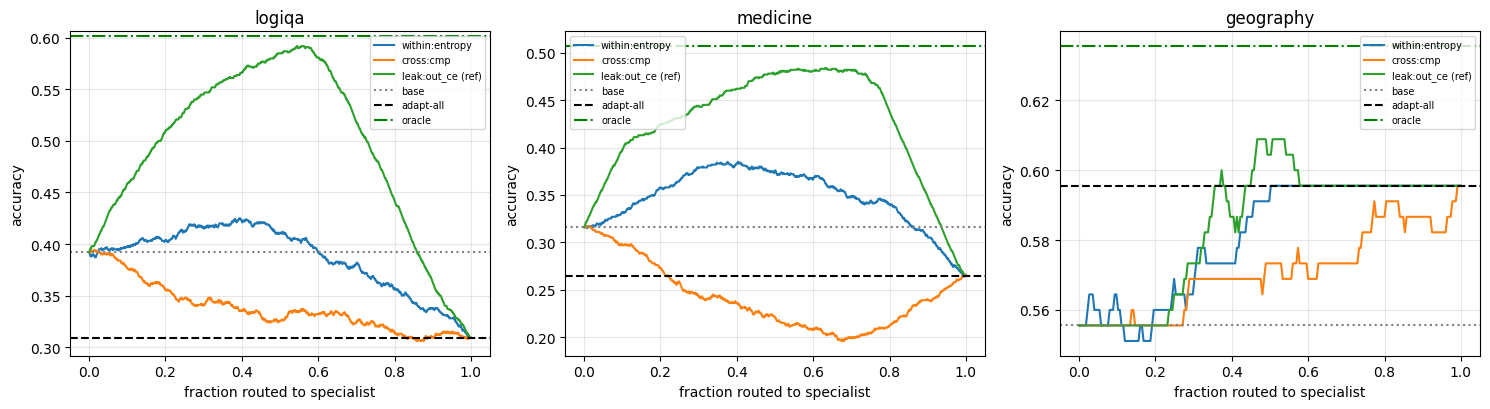

In [16]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5*len(DATASETS), 4.2), squeeze=False)
for ci, ds in enumerate(DATASETS):
    ax = axes[0][ci]
    scoremaps = {"within:entropy": {i: BCONF[ds][i]["mean_entropy"] for i in BCONF[ds]},
                 "cross:cmp": CMP[ds]["route_region"],
                 "leak:out_ce (ref)": {f["idx"]: f["out_ce"] for f in FEATS[ds]}}
    for name, sm2 in scoremaps.items():
        fr, acc, bacc, aacc, orc = routed_curve(ds, "route_region", sm2)
        ax.plot(fr, acc, label=name)
    ax.axhline(bacc, color="grey", ls=":", label="base")
    ax.axhline(aacc, color="black", ls="--", label="adapt-all")
    ax.axhline(orc, color="green", ls="-.", label="oracle")
    ax.set_title(ds); ax.set_xlabel("fraction routed to specialist"); ax.set_ylabel("accuracy")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
# ---- full-arm + blended-router deployable evaluation (no generation, reads caches) ----
import json, numpy as np, pandas as pd
from pathlib import Path
sys.path.insert(0, str(SCRIPTS)); import grading
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    HAVE_SK = True
except Exception:
    HAVE_SK = False; print("sklearn missing -> blend = mean-z fallback")

SC_ROOT = Path(WORK) / "saves_regime"      # optional self-consistency cache (if you ran the regime nb)
RNG = np.random.RandomState(0)

def _graded(path, at):
    ok = {}
    for ln in open(path, encoding="utf-8"):
        r = json.loads(ln); ex = grading.extract(str(r.get("predict", "")), at)
        ok[int(r["idx"])] = bool(grading.is_correct(ex.value, str(r["label"]), at))
    return ok

def _auroc(y, s):
    y = np.asarray(y); s = np.asarray(s, float)
    m = ~np.isnan(s); y, s = y[m], s[m]
    pos, neg = y == 1, y == 0
    if pos.sum() == 0 or neg.sum() == 0: return float("nan")
    order = np.argsort(s); ranks = np.empty(len(s)); ranks[order] = np.arange(1, len(s) + 1)
    return (ranks[pos].sum() - pos.sum() * (pos.sum() + 1) / 2) / (pos.sum() * neg.sum())

def _best_frac(score, b, a, tr):
    s = score[tr]; order = np.argsort(-s); best, bp = -1, 0.0
    for k in range(0, len(tr) + 1):
        r = np.zeros(len(tr), bool); r[order[:k]] = True
        acc = np.mean(np.where(r, a[tr], b[tr]))
        if acc > best: best, bp = acc, k / max(1, len(tr))
    return bp

def _routed(score, b, a, te, frac):
    s = score[te]; order = np.argsort(-s); k = int(round(frac * len(te)))
    r = np.zeros(len(te), bool); r[order[:k]] = True
    return np.mean(np.where(r, a[te], b[te]))

rows = []
for ds in DATASETS:
    at = grading.detect_answer_type(ds)
    bconf = {int(k): v for k, v in json.load(open(ROOT / ds / "base_conf.json")).items()}
    out_ce = {f["idx"]: f["out_ce"] for f in
              (json.loads(l) for l in open(ROOT / ds / "pool_gtp" / "features.jsonl") if l.strip())}
    base_ok_d = _graded(ROOT / ds / "preds_base.jsonl", at)
    scp = SC_ROOT / ds / "sc_agreement.json"
    sc_d = {int(k): v for k, v in json.load(open(scp)).items()} if scp.exists() else {}
    for arm in ARMS:
        adapt_ok_d = _graded(ROOT / ds / arm / "preds_adapted.jsonl", at)
        cmpp = ROOT / ds / arm / "cmp.json"
        cmp_d = {int(k): v for k, v in json.load(open(cmpp)).items()} if cmpp.exists() else {}
        idxs = np.array(sorted(i for i in bconf if i in base_ok_d and i in adapt_ok_d))
        n = len(idxs)
        b = np.array([base_ok_d[i] for i in idxs], float)
        a = np.array([adapt_ok_d[i] for i in idxs], float)
        yw = 1 - b
        ent = np.array([bconf[i]["mean_entropy"] for i in idxs])
        m1p = np.array([1 - bconf[i]["mean_prob"] for i in idxs])
        mnp = np.array([1 - bconf[i]["min_prob"] for i in idxs])
        feat = [ent, m1p, mnp]
        if sc_d:
            sc = np.array([1 - sc_d.get(i, np.nan) for i in idxs])
            sc = np.where(np.isnan(sc), np.nanmedian(sc), sc); feat.append(sc)
        X = np.vstack(feat).T
        oce = np.array([out_ce.get(i, np.nan) for i in idxs])
        cmv = np.array([cmp_d.get(i, np.nan) for i in idxs]) if cmp_d else np.full(n, np.nan)
        perm = RNG.permutation(n); tr, te = perm[:n // 2], perm[n // 2:]
        if HAVE_SK and len(np.unique(yw[tr])) > 1:
            sx = StandardScaler().fit(X[tr])
            lr = LogisticRegression(max_iter=200).fit(sx.transform(X[tr]), yw[tr])
            blend = lr.predict_proba(sx.transform(X))[:, 1]
        else:
            blend = ((X - X[tr].mean(0)) / (X[tr].std(0) + 1e-9)).mean(1)
        sigs = {"within:entropy": ent, "within:blend": blend, "leak:out_ce": oce, "cross:cmp": cmv}
        base_te, adapt_te = b[te].mean(), a[te].mean()
        oracle_te = np.maximum(b[te], a[te]).mean()
        for name, sig in sigs.items():
            if np.all(np.isnan(sig)): continue
            p = _best_frac(sig, b, a, tr)
            rows.append({"dataset": ds, "arm": arm, "signal": name,
                         "test_AUROC": round(_auroc(yw[te], sig[te]), 3),
                         "base": round(base_te, 3), "adapt_all": round(adapt_te, 3),
                         "routed(deploy)": round(_routed(sig, b, a, te, p), 3),
                         "vs_adapt": round(_routed(sig, b, a, te, p) - adapt_te, 3),
                         "oracle": round(oracle_te, 3), "frac": round(p, 2)})
df = pd.DataFrame(rows)
pd.set_option("display.width", 240); pd.set_option("display.max_rows", 100)
print(df.to_string(index=False))

print("\n=== DEPLOYABLE go/no-go: best label-free router vs strong adapt-all (held-out test) ===")
for ds in DATASETS:
    for arm in ARMS:
        g = df[(df.dataset == ds) & (df.arm == arm) & (df.signal.isin(["within:entropy", "within:blend"]))]
        if g.empty: continue
        best = g.loc[g["routed(deploy)"].idxmax()]
        v = "BEATS adapt-all" if best["vs_adapt"] > 0 else "loses"
        print(f"{ds:10s} {arm:12s}: {best['signal']:14s} routed={best['routed(deploy)']:.3f} "
              f"adapt_all={best['adapt_all']:.3f} ({best['vs_adapt']:+.3f})  AUROC={best['test_AUROC']:.3f} -> {v}")

  dataset          arm         signal  test_AUROC  base  adapt_all  routed(deploy)  vs_adapt  oracle  frac
   logiqa route_region within:entropy       0.669 0.424      0.302           0.436     0.134   0.620  0.39
   logiqa route_region   within:blend       0.654 0.424      0.302           0.428     0.126   0.620  0.45
   logiqa route_region    leak:out_ce       0.992 0.424      0.302           0.584     0.282   0.620  0.60
   logiqa route_region      cross:cmp       0.392 0.424      0.302           0.418     0.116   0.620  0.05
   logiqa         full within:entropy       0.646 0.408      0.468           0.462    -0.006   0.542  0.75
   logiqa         full   within:blend       0.641 0.408      0.468           0.460    -0.008   0.542  0.73
   logiqa         full    leak:out_ce       0.991 0.408      0.468           0.518     0.050   0.542  0.63
   logiqa         full      cross:cmp       0.401 0.408      0.468           0.468     0.000   0.542  1.00
 medicine route_region within:entropy

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [18]:
# ---- concordance pre-test: is the DISAGREEMENT region an easier routing problem? (cache-only) ----
import json, numpy as np, pandas as pd
from pathlib import Path
sys.path.insert(0, str(SCRIPTS)); import grading

def _gmap(path, at):
    m = {}
    for ln in open(path, encoding="utf-8"):
        r = json.loads(ln); ex = grading.extract(str(r.get("predict", "")), at)
        m[int(r["idx"])] = (ex.value, bool(grading.is_correct(ex.value, str(r["label"]), at)))
    return m

def _auroc(y, s):
    y = np.asarray(y); s = np.asarray(s, float); m = ~np.isnan(s); y, s = y[m], s[m]
    pos, neg = y == 1, y == 0
    if pos.sum() == 0 or neg.sum() == 0: return float("nan")
    o = np.argsort(s); r = np.empty(len(s)); r[o] = np.arange(1, len(s) + 1)
    return (r[pos].sum() - pos.sum() * (pos.sum() + 1) / 2) / (pos.sum() * neg.sum())

rows = []
for ds in DATASETS:
    at = grading.detect_answer_type(ds)
    base = _gmap(ROOT / ds / "preds_base.jsonl", at)
    bconf = {int(k): v for k, v in json.load(open(ROOT / ds / "base_conf.json")).items()}
    for arm in ARMS:
        adp = _gmap(ROOT / ds / arm / "preds_adapted.jsonl", at)
        idx = [i for i in base if i in adp and base[i][0] is not None and adp[i][0] is not None]
        agree = [i for i in idx if base[i][0] == adp[i][0]]
        dis   = [i for i in idx if base[i][0] != adp[i][0]]
        one = [i for i in dis if base[i][1] != adp[i][1]]
        adapter_wins = [i for i in one if adp[i][1]]
        y = np.array([1 if adp[i][1] else 0 for i in one])
        ent = np.array([bconf[i]["mean_entropy"] if i in bconf else np.nan for i in one])
        au = _auroc(y, ent)
        acc_agree = np.mean([base[i][1] for i in agree]) if agree else float("nan")
        base_all  = np.mean([base[i][1] for i in idx])
        adapt_all = np.mean([adp[i][1] for i in idx])
        concord_oracle = (sum(base[i][1] for i in agree) +
                          sum(max(base[i][1], adp[i][1]) for i in dis)) / len(idx)
        rows.append({
            "dataset": ds, "arm": arm,
            "%agree": round(100 * len(agree) / len(idx), 1),
            "acc_agree": round(acc_agree, 3),
            "n_disagree": len(dis),
            "dis_base_wins": sum(1 for i in one if base[i][1]),
            "dis_adapter_wins": len(adapter_wins),
            "dis_both_wrong": len(dis) - len(one),
            "AUROC_entropy_in_dis": round(au, 3),
            "base": round(base_all, 3), "adapt_all": round(adapt_all, 3),
            "concord_ceiling": round(concord_oracle, 3),
        })
df = pd.DataFrame(rows)
pd.set_option("display.width", 240)
print(df.to_string(index=False))

  dataset          arm  %agree  acc_agree  n_disagree  dis_base_wins  dis_adapter_wins  dis_both_wrong  AUROC_entropy_in_dis  base  adapt_all  concord_ceiling
   logiqa route_region    15.5      0.639         845            293               210             342                 0.651 0.392      0.309            0.602
   logiqa         full    62.6      0.505         374             76               141             157                 0.508 0.392      0.457            0.533
 medicine route_region    19.0      0.471         671            242               128             301                 0.653 0.382      0.244            0.536
 medicine         full    47.8      0.538         432            103               170             159                 0.474 0.382      0.463            0.587
geography route_region    81.8      0.630          41              9                18              14                 0.321 0.556      0.596            0.636
geography         full    75.6      0.659     

In [19]:
# ---- soft probability fusion (ensemble, NO router): the last mechanism-level swing ----
import json, numpy as np, pandas as pd, torch, gc
from pathlib import Path
sys.path.insert(0, str(SCRIPTS)); import grading

def choice_letters(ds):
    labs = set()
    for r in json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]:
        o = str(r.get("output", "")).strip()
        if o and o[0].isalpha(): labs.add(o[0].upper())
    return sorted(labs) or ["A", "B", "C", "D"]

def choice_logprobs(model_path, ds, letters):
    model, tok = load_lm(model_path); dev = next(model.parameters()).device
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    lids = {L: tok(L, add_special_tokens=False)["input_ids"][-1] for L in letters}
    out = {}
    for s in range(0, len(recs), GEN_BATCH):
        chunk = list(range(s, min(s + GEN_BATCH, len(recs))))
        enc = tok([wrap(tok, _build_user(recs[i])) for i in chunk], return_tensors="pt",
                  padding=True, truncation=True, max_length=2048).to(dev)
        with torch.inference_mode():
            lp = torch.log_softmax(model(**enc).logits[:, -1, :].float(), -1).cpu().numpy()
        for bi, i in enumerate(chunk):
            out[i] = {L: float(lp[bi, lids[L]]) for L in letters}
    del model; gc.collect(); torch.cuda.empty_cache()
    return out

rows = []
for ds in DATASETS:
    at = grading.detect_answer_type(ds); letters = choice_letters(ds)
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    gold = {i: grading.extract(str(recs[i].get("output", "")), at).value
            for i in range(len(recs)) if recs[i].get("output")}
    blp = choice_logprobs(MODEL, ds, letters)
    letter_mass = float(np.mean([np.exp(list(blp[i].values())).sum() for i in blp]))
    for arm in ARMS:
        alp = choice_logprobs(str(ROOT / ds / arm / "adapter" / "merged"), ds, letters)
        idx = np.array([i for i in blp if i in alp and i in gold])
        def am(d): return max(letters, key=lambda L: d[L])
        def ok(pred, i): return bool(grading.is_correct(pred, gold[i], at))
        perm = np.random.RandomState(0).permutation(idx); tr, te = perm[: len(idx)//2], perm[len(idx)//2:]
        def fuse_acc(w, sel):
            return np.mean([ok(max(letters, key=lambda L: (1-w)*blp[i][L] + w*alp[i][L]), i) for i in sel])
        ws = np.linspace(0, 1, 21); best_w = float(ws[int(np.argmax([fuse_acc(w, tr) for w in ws]))])
        base_te  = np.mean([ok(am(blp[i]), i) for i in te])
        adpt_te  = np.mean([ok(am(alp[i]), i) for i in te])
        fuse_te  = fuse_acc(best_w, te)
        orac_te  = np.mean([ok(am(blp[i]), i) or ok(am(alp[i]), i) for i in te])
        rows.append({"dataset": ds, "arm": arm, "letter_mass": round(letter_mass, 2),
                     "base": round(base_te, 3), "adapt_all": round(adpt_te, 3),
                     "fused": round(fuse_te, 3), "best_w": round(best_w, 2),
                     "vs_adapt": round(fuse_te - adpt_te, 3), "oracle": round(orac_te, 3)})
df = pd.DataFrame(rows)
pd.set_option("display.width", 240); print(df.to_string(index=False))

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

  dataset          arm  letter_mass  base  adapt_all  fused  best_w  vs_adapt  oracle
   logiqa route_region         0.97 0.422      0.304  0.426    0.55     0.122   0.622
   logiqa         full         0.97 0.422      0.464  0.464    1.00     0.000   0.562
 medicine route_region         0.96 0.378      0.260  0.378    0.00     0.118   0.474
 medicine         full         0.96 0.378      0.450  0.442    0.90    -0.008   0.574
geography route_region         0.99 0.540      0.593  0.584    0.90    -0.009   0.628
geography         full         0.99 0.540      0.584  0.593    0.85     0.009   0.664


In [20]:
# ---- adapter-COMBINATION pre-test: is there headroom from combining diverse adapters? (cache-only) ----
import json, numpy as np, pandas as pd
from collections import Counter
from pathlib import Path
sys.path.insert(0, str(SCRIPTS)); import grading

def preds_map(path, at):
    m = {}
    for ln in open(path):
        r = json.loads(ln); m[int(r["idx"])] = grading.extract(str(r.get("predict", "")), at).value
    return m

rows = []
for ds in DATASETS:
    at = grading.detect_answer_type(ds)
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    gold = {i: grading.extract(str(recs[i].get("output", "")), at).value
            for i in range(len(recs)) if recs[i].get("output")}
    P = {"base": preds_map(ROOT / ds / "preds_base.jsonl", at)}
    for arm in ARMS: P[arm] = preds_map(ROOT / ds / arm / "preds_adapted.jsonl", at)
    idx = [i for i in gold if all(i in P[k] for k in P)]
    def acc(k): return np.mean([grading.is_correct(P[k][i], gold[i], at) for i in idx])
    def okset(i): return {k: grading.is_correct(P[k][i], gold[i], at) for k in P}
    order = ["full", "base"] + [a for a in ARMS if a != "full"]
    def vote(i):
        c = Counter(P[k][i] for k in P); best = c.most_common()[0][1]
        cands = [a for a, n in c.items() if n == best]
        for k in order:
            if P[k][i] in cands: return P[k][i]
        return cands[0]
    vote_acc = np.mean([grading.is_correct(vote(i), gold[i], at) for i in idx])
    orc2 = np.mean([max(okset(i)["base"], okset(i)["full"]) for i in idx])
    orc_all = np.mean([max(okset(i).values()) for i in idx])
    rows.append({"dataset": ds, "base": round(acc("base"), 3), "adapt_all": round(acc("full"), 3),
                 "specialist": round(acc("route_region"), 3),
                 "majority_vote": round(vote_acc, 3), "vote_vs_adapt": round(vote_acc - acc("full"), 3),
                 "orc{base,full}": round(orc2, 3), "orc{+spec}": round(orc_all, 3),
                 "diversity_gain": round(orc_all - orc2, 3)})
print(pd.DataFrame(rows).to_string(index=False))
print("\ndiversity_gain>0 => specialist covers errors base+full BOTH miss (diverse adapters add real coverage)")
print("vote_vs_adapt>0 => a parameter-free vote already beats adapt-all")

  dataset  base  adapt_all  specialist  majority_vote  vote_vs_adapt  orc{base,full}  orc{+spec}  diversity_gain
   logiqa 0.392      0.457       0.309          0.455         -0.002           0.533       0.664           0.131
 medicine 0.316      0.445       0.265          0.447          0.002           0.548       0.677           0.129
geography 0.556      0.636       0.596          0.613         -0.022           0.693       0.711           0.018

diversity_gain>0 => specialist covers errors base+full BOTH miss (diverse adapters add real coverage)
vote_vs_adapt>0 => a parameter-free vote already beats adapt-all


In [21]:
# ---- confidence-weighted vote over {base, full, specialist}: fast tell before any training ----
import json, numpy as np, pandas as pd
from collections import Counter
from pathlib import Path
sys.path.insert(0, str(SCRIPTS)); import grading

def preds_map(path, at):
    m = {}
    for ln in open(path):
        r = json.loads(ln); m[int(r["idx"])] = grading.extract(str(r.get("predict", "")), at).value
    return m

def conf_map(path):
    if not Path(path).exists(): return None
    return {int(k): float(v["mean_prob"]) for k, v in json.load(open(path)).items()}

rows = []
for ds in DATASETS:
    at = grading.detect_answer_type(ds)
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    gold = {i: grading.extract(str(recs[i].get("output", "")), at).value
            for i in range(len(recs)) if recs[i].get("output")}
    members = {"base": ROOT / ds / "preds_base.jsonl"}
    for arm in ARMS: members[arm] = ROOT / ds / arm / "preds_adapted.jsonl"
    P = {k: preds_map(p, at) for k, p in members.items()}
    bconf = conf_map(ROOT / ds / "base_conf.json")
    def wconf(k, i):
        if k == "base" and bconf is not None and i in bconf: return bconf[i]
        return 0.5
    idx = [i for i in gold if all(i in P[k] for k in P)]
    def acc_of(predfn): return np.mean([grading.is_correct(predfn(i), gold[i], at) for i in idx])
    def equal_vote(i):
        return Counter(P[k][i] for k in P).most_common(1)[0][0]
    def cw_vote(i):
        score = {}
        for k in P: score[P[k][i]] = score.get(P[k][i], 0.0) + wconf(k, i)
        return max(score, key=score.get)
    def decorr_vote(i):
        votes = [P["base"][i], P["full"][i]] + [P[a][i] for a in ARMS if a != "full"]
        c = Counter(votes); spec = [a for a in ARMS if a != "full"]
        if spec:
            sv = P[spec[0]][i]
            if c[sv] >= c.most_common(1)[0][1]: return sv
        return c.most_common(1)[0][0]
    base_acc = acc_of(lambda i: P["base"][i]); adapt_acc = acc_of(lambda i: P["full"][i])
    rows.append({
        "dataset": ds, "base": round(base_acc, 3), "adapt_all": round(adapt_acc, 3),
        "equal_vote": round(acc_of(equal_vote), 3),
        "conf_wt_vote": round(acc_of(cw_vote), 3),
        "decorr_vote": round(acc_of(decorr_vote), 3),
        "cw_vs_adapt": round(acc_of(cw_vote) - adapt_acc, 3),
        "decorr_vs_adapt": round(acc_of(decorr_vote) - adapt_acc, 3),
    })
df = pd.DataFrame(rows)
pd.set_option("display.width", 240); print(df.to_string(index=False))

  dataset  base  adapt_all  equal_vote  conf_wt_vote  decorr_vote  cw_vs_adapt  decorr_vs_adapt
   logiqa 0.392      0.457       0.425         0.425        0.434       -0.032           -0.023
 medicine 0.316      0.445       0.359         0.359        0.389       -0.086           -0.056
geography 0.556      0.636       0.600         0.600        0.600       -0.036           -0.036


In [22]:
# ---- cache-only regrade: how does your adapter score under TLM's metric (Rouge-Lsum)? ----
import json, numpy as np, pandas as pd
from pathlib import Path
try:
    import subprocess, sys as _s; subprocess.run([_s.executable,"-m","pip","install","-q","rouge-score"], check=False)
    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(["rougeLsum"], use_stemmer=True)
    def rougeL(pred, ref): return scorer.score(ref or "", pred or "")["rougeLsum"].fmeasure
    METRIC = "rougeLsum(rouge_score)"
except Exception:
    def _lcs(a, b):
        a, b = a.split(), b.split()
        if not a or not b: return 0
        d = [[0]*(len(b)+1) for _ in range(len(a)+1)]
        for i in range(1, len(a)+1):
            for j in range(1, len(b)+1):
                d[i][j] = d[i-1][j-1]+1 if a[i-1]==b[j-1] else max(d[i-1][j], d[i][j-1])
        return d[-1][-1]
    def rougeL(pred, ref):
        pred = pred or ""; ref = ref or ""; l = _lcs(pred, ref)
        if l == 0: return 0.0
        p = l/len(pred.split()); r = l/len(ref.split()); return 2*p*r/(p+r)
    METRIC = "rougeL(LCS-fallback)"

def field(r, *names):
    for n in names:
        if n in r and r[n] is not None: return str(r[n])
    return ""

rows = []
for ds in DATASETS:
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    gold = {i: str(recs[i].get("output", "")).strip() for i in range(len(recs)) if recs[i].get("output")}
    arms = {"base": ROOT / ds / "preds_base.jsonl"}
    for a in ARMS: arms[a] = ROOT / ds / a / "preds_adapted.jsonl"
    entry = {"dataset": ds}
    for name, path in arms.items():
        if not Path(path).exists(): continue
        sc = []
        for ln in open(path):
            r = json.loads(ln); i = int(r["idx"])
            if i not in gold: continue
            sc.append(rougeL(field(r, "predict", "prediction", "output", "response"), gold[i]))
        entry[name] = round(float(np.mean(sc)), 4) if sc else None
    for a in ARMS:
        if a in entry and "base" in entry and entry[a] is not None:
            entry[f"{a}-base"] = round(entry[a] - entry["base"], 4)
    rows.append(entry)
df = pd.DataFrame(rows)
pd.set_option("display.width", 220)
print("metric:", METRIC); print(df.to_string(index=False))

metric: rougeLsum(rouge_score)
  dataset   base  route_region   full  route_region-base  full-base
   logiqa 0.3910        0.3090 0.4570            -0.0820     0.0660
 medicine 0.2707        0.2650 0.4450            -0.0057     0.1743
geography 0.5556        0.5956 0.6356             0.0400     0.0800


## How to read this

**AUROC (cell 4) is the verdict.** It's the deployable ceiling for a router, no threshold needed.
- Any signal **> ~0.70** (especially `cross: cmp`): a label-free router exists -> the exploitation claim is on the table, and you route by that signal. Compare `cross: cmp` vs `within: entropy` -- CMP predicts cross-model wins; if it does, that's your router *and* a clean reason it beats the naive confidence baseline reviewers will expect.
- Everything **~0.55-0.6**: no deployable router. `ce_q` wasn't a bug, it's the regime -- within-model confidence is blind here (matches the CMP paper's confident-error finding). Then the paper stays the **phenomenon** (oracle ceiling is real but unreachable label-free), stated honestly.

**Routed curves (cell 5-6)** show the payoff shape. `leak:out_ce` is the gold-answer upper bound; the gap between it and `cross:cmp` is what you lose going label-free. If `cross:cmp` tracks `out_ce`, you've closed the deployability gap that sank `ce_q`.

**Caveats to honor in the writeup:** best_routed in cell 5 uses an oracle threshold, so cite AUROC as the real (threshold-free) number; and add more verifiable datasets so a positive AUROC is a trend, not one dataset. Knob: if CMP is weak, also try base->adapter direction (base's surprise at the adapter's answer) and their difference.